## 1. Carga de Datos

In [1]:
!mkdir -p data

!curl -o data/winequality-red.csv \
    https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv

!curl -o data/winequality-white.csv \
    https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv

# Verificar
!wc -l data/winequality-*.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 84199    0 84199    0     0  59869      0 --:--:--  0:00:01 --:--:-- 59885
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  258k    0  258k    0     0   188k      0 --:--:--  0:00:01 --:--:--  188k
  1600 data/winequality-red.csv
  4899 data/winequality-white.csv
  6499 total


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Cargar dataset (separador es punto y coma)
df = pd.read_csv('data/winequality-red.csv', sep=';')

print(f"Shape: {df.shape}")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
df.head(10)

Shape: (1599, 12)
Filas: 1599, Columnas: 12


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


## 2. Información General

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [4]:
# Verificar valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())
print(f"\nTotal nulos: {df.isnull().sum().sum()}")

Valores nulos por columna:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Total nulos: 0


In [5]:
# Verificar duplicados
duplicados = df.duplicated().sum()
print(f"Filas duplicadas: {duplicados} ({duplicados/len(df)*100:.1f}%)")

Filas duplicadas: 240 (15.0%)


In [6]:
df.describe().round(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000
mean,8.320,0.528,0.271,2.539,0.087,15.875,46.468,0.997,3.311,0.658,10.423,5.636
std,1.741,0.179,0.195,1.410,0.047,10.460,32.895,0.002,0.154,0.170,1.066,0.808
min,4.600,0.120,0.000,0.900,0.012,1.000,6.000,0.990,2.740,0.330,8.400,3.000
25%,7.100,0.390,0.090,1.900,0.070,7.000,22.000,0.996,3.210,0.550,9.500,5.000
50%,7.900,0.520,0.260,2.200,0.079,14.000,38.000,0.997,3.310,0.620,10.200,6.000
75%,9.200,0.640,0.420,2.600,0.090,21.000,62.000,0.998,3.400,0.730,11.100,6.000
max,15.900,1.580,1.000,15.500,0.611,72.000,289.000,1.004,4.010,2.000,14.900,8.000


## 3. Estadísticas Descriptivas

In [7]:
# Estadísticas adicionales: asimetría y curtosis
stats_extra = pd.DataFrame({
    'skewness': df.skew(),
    'kurtosis': df.kurtosis()
}).round(3)

print("Asimetría y Curtosis:")
stats_extra

Asimetría y Curtosis:


,skewness,kurtosis
fixed acidity,0.983,1.132
volatile acidity,0.672,1.226
citric acid,0.318,-0.789
residual sugar,4.541,28.618
chlorides,5.680,41.716
free sulfur dioxide,1.251,2.024
total sulfur dioxide,1.516,3.810
density,0.071,0.934
pH,0.194,0.807
sulphates,2.429,11.720


## 4. Variable Objetivo: Quality

In [8]:
print("Distribución de quality:")
print(df['quality'].value_counts().sort_index())
print(f"\nMedia: {df['quality'].mean():.2f}")
print(f"Mediana: {df['quality'].median():.0f}")

Distribución de quality:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

Media: 5.64
Mediana: 6


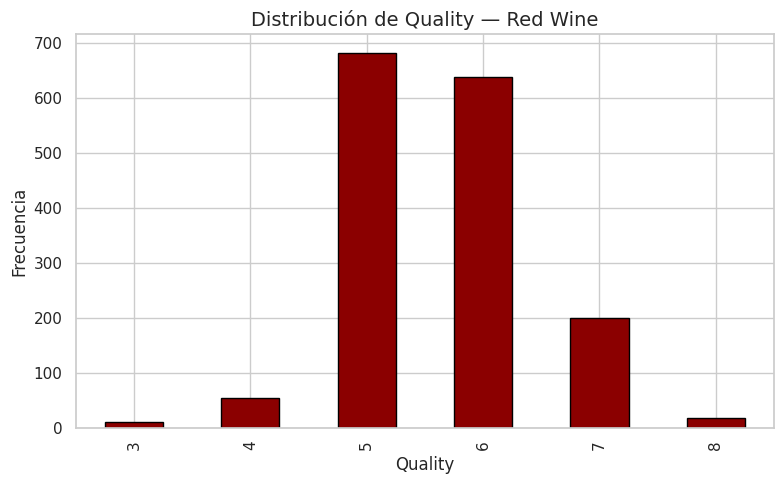

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
df['quality'].value_counts().sort_index().plot(kind='bar', color='#8B0000', edgecolor='black', ax=ax)
ax.set_title('Distribución de Quality — Red Wine', fontsize=14)
ax.set_xlabel('Quality')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

In [10]:
# Crear variable binaria (como en la práctica: quality >= 7 → good wine)
df['quality_binary'] = (df['quality'] >= 7).astype(int)

print("Clasificación binaria (threshold = 7):")
print(df['quality_binary'].value_counts().rename({0: 'Bad (< 7)', 1: 'Good (>= 7)'}))
print(f"\nBalance clase positiva: {df['quality_binary'].mean():.2%}")

Clasificación binaria (threshold = 7):
quality_binary
Bad (< 7)      1382
Good (>= 7)     217
Name: count, dtype: int64

Balance clase positiva: 13.57%


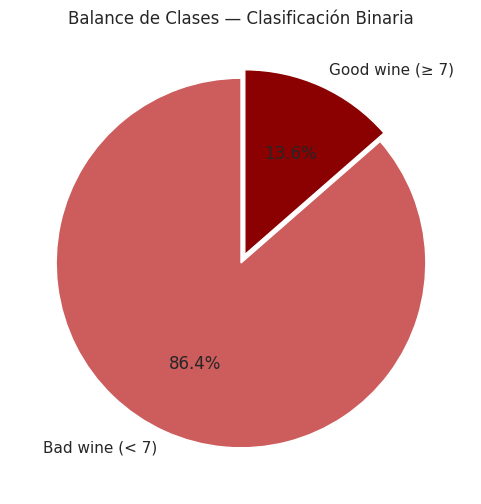

In [11]:
fig, ax = plt.subplots(figsize=(6, 6))
counts = df['quality_binary'].value_counts()
ax.pie(counts, labels=['Bad wine (< 7)', 'Good wine (≥ 7)'],
       autopct='%1.1f%%', colors=['#CD5C5C', '#8B0000'],
       startangle=90, explode=(0, 0.05))
ax.set_title('Balance de Clases — Clasificación Binaria')
plt.show()

## 5. Distribuciones de Features

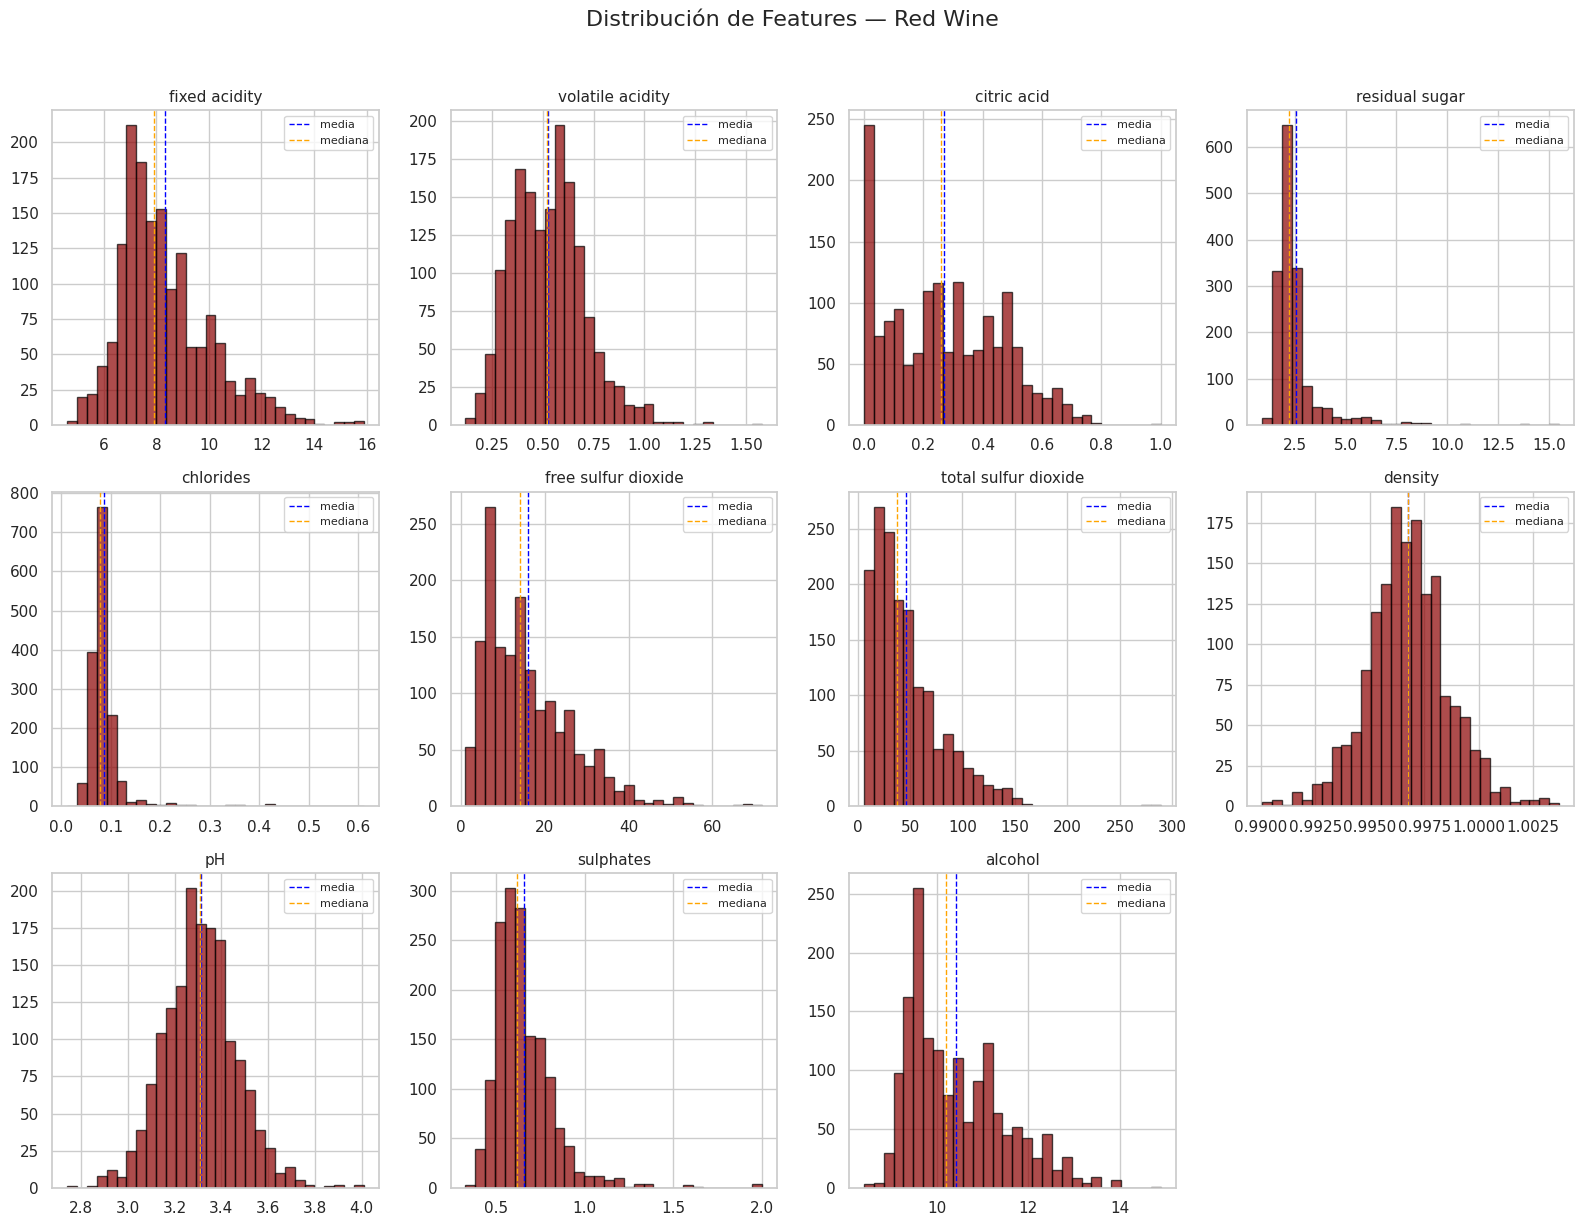

In [12]:
features = [col for col in df.columns if col not in ['quality', 'quality_binary']]

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=30, color='#8B0000', edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=11)
    axes[i].axvline(df[col].mean(), color='blue', linestyle='--', linewidth=1, label='media')
    axes[i].axvline(df[col].median(), color='orange', linestyle='--', linewidth=1, label='mediana')
    axes[i].legend(fontsize=8)

# Ocultar subplot vacío si lo hay
for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de Features — Red Wine', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

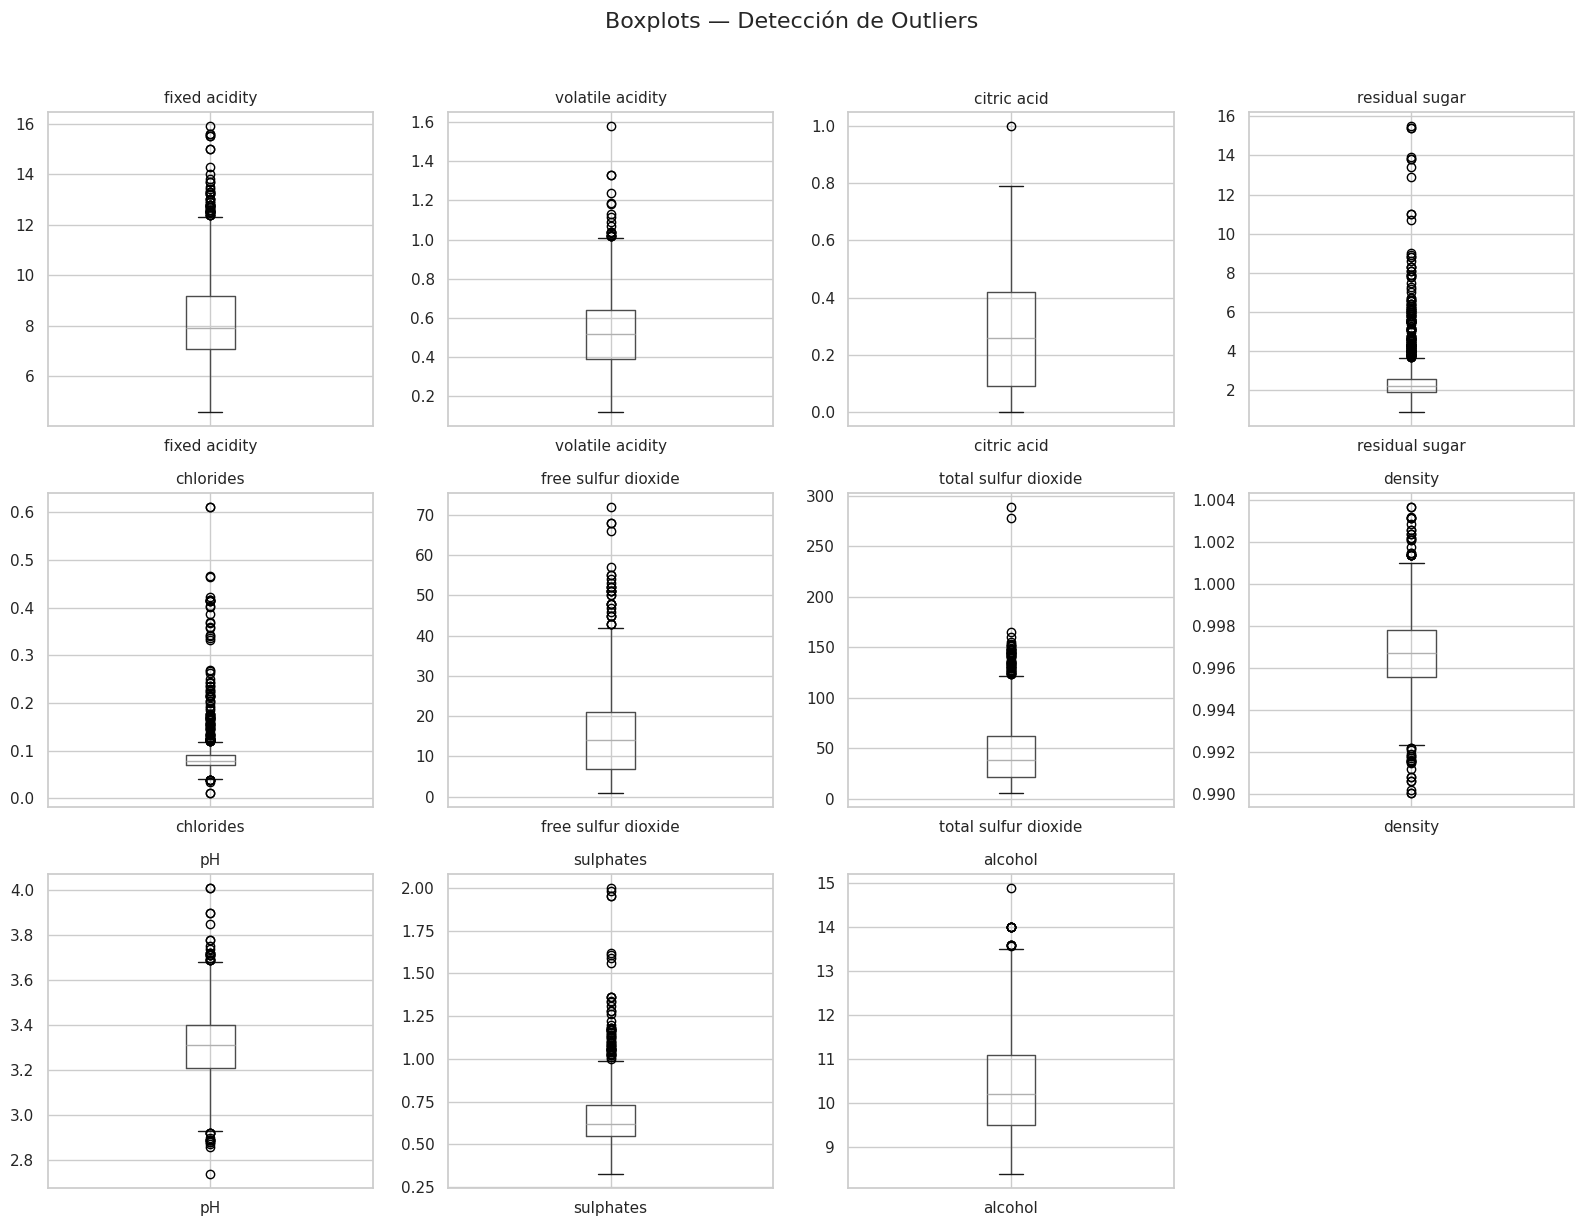

In [13]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    df.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col, fontsize=11)

for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots — Detección de Outliers', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [14]:
# Cuantificar outliers con IQR
print("Outliers por feature (método IQR):")
print("-" * 45)
for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"  {col:.<30} {n_outliers:>4} ({n_outliers/len(df)*100:.1f}%)")

Outliers por feature (método IQR):
---------------------------------------------
  fixed acidity.................   49 (3.1%)
  volatile acidity..............   19 (1.2%)
  citric acid...................    1 (0.1%)
  residual sugar................  155 (9.7%)
  chlorides.....................  112 (7.0%)
  free sulfur dioxide...........   30 (1.9%)
  total sulfur dioxide..........   55 (3.4%)
  density.......................   45 (2.8%)
  pH............................   35 (2.2%)
  sulphates.....................   59 (3.7%)
  alcohol.......................   13 (0.8%)


## 7. Matriz de Correlación

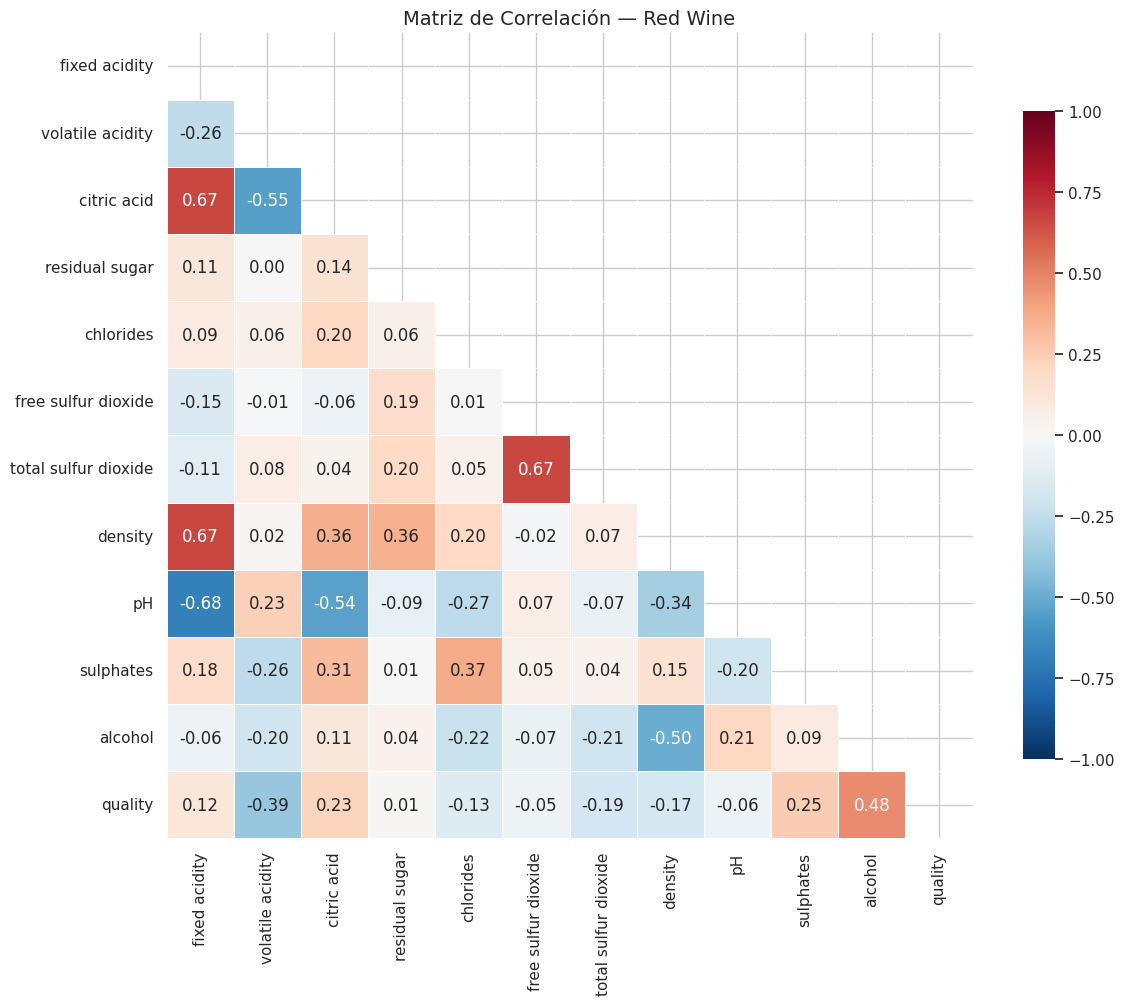

In [15]:
corr = df[features + ['quality']].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de Correlación — Red Wine', fontsize=14)
plt.tight_layout()
plt.show()

In [16]:
# Top correlaciones con quality
print("Correlación de features con quality:")
print("-" * 40)
corr_quality = df[features].corrwith(df['quality']).sort_values(ascending=False)
for feat, val in corr_quality.items():
    bar = '█' * int(abs(val) * 30)
    sign = '+' if val > 0 else '-'
    print(f"  {feat:.<30} {sign}{abs(val):.3f}  {bar}")

Correlación de features con quality:
----------------------------------------
  alcohol....................... +0.476  ██████████████
  sulphates..................... +0.251  ███████
  citric acid................... +0.226  ██████
  fixed acidity................. +0.124  ███
  residual sugar................ +0.014  
  free sulfur dioxide........... -0.051  █
  pH............................ -0.058  █
  chlorides..................... -0.129  ███
  density....................... -0.175  █████
  total sulfur dioxide.......... -0.185  █████
  volatile acidity.............. -0.391  ███████████


## 8. Features vs Quality (Bivariado)

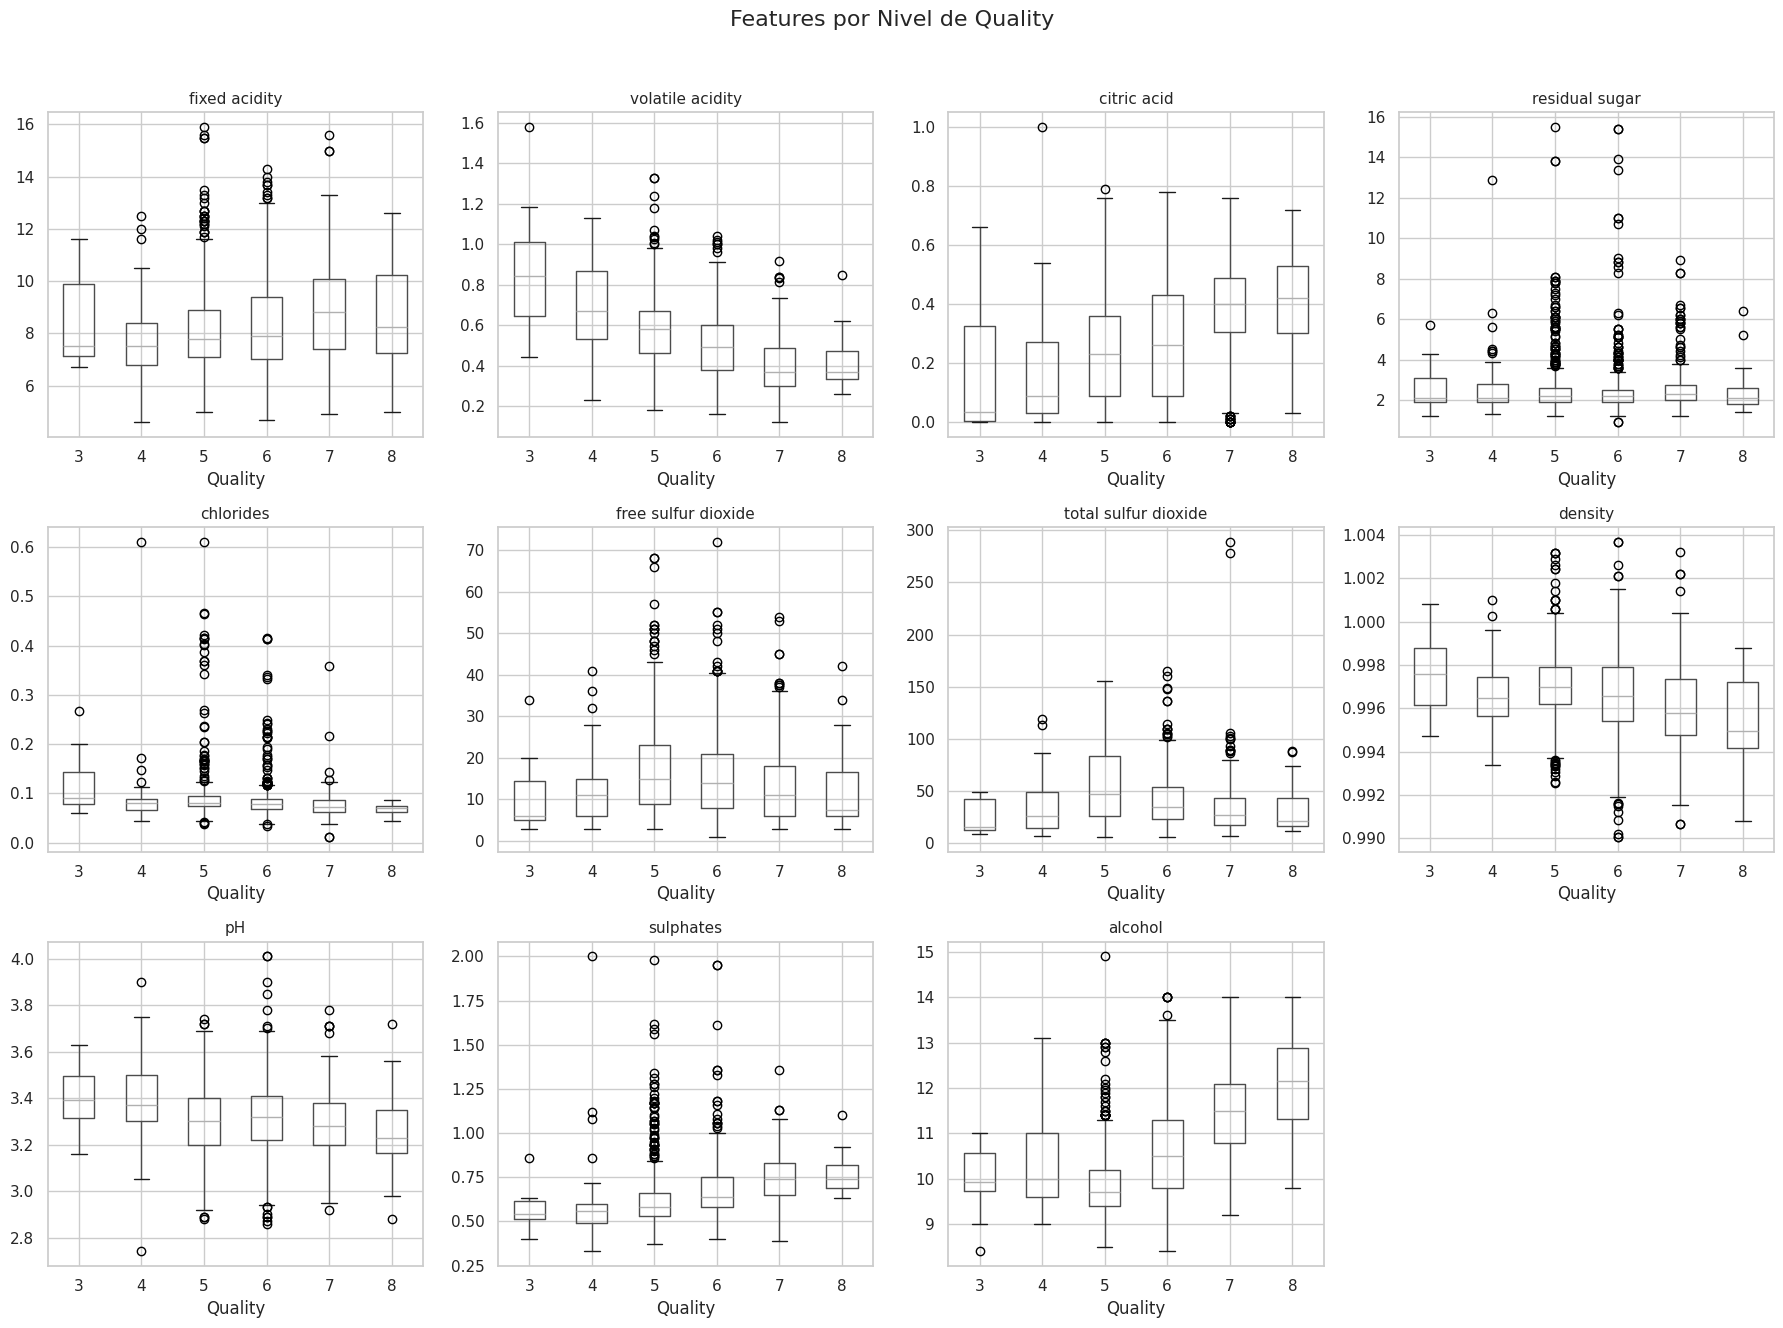

In [17]:
fig, axes = plt.subplots(3, 4, figsize=(18, 13))
axes = axes.flatten()

for i, col in enumerate(features):
    df.boxplot(column=col, by='quality', ax=axes[i])
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('Quality')

for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Features por Nivel de Quality', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 9. Pairplot (Features más correlacionadas)

Top features: ['alcohol', 'volatile acidity', 'sulphates', 'citric acid']


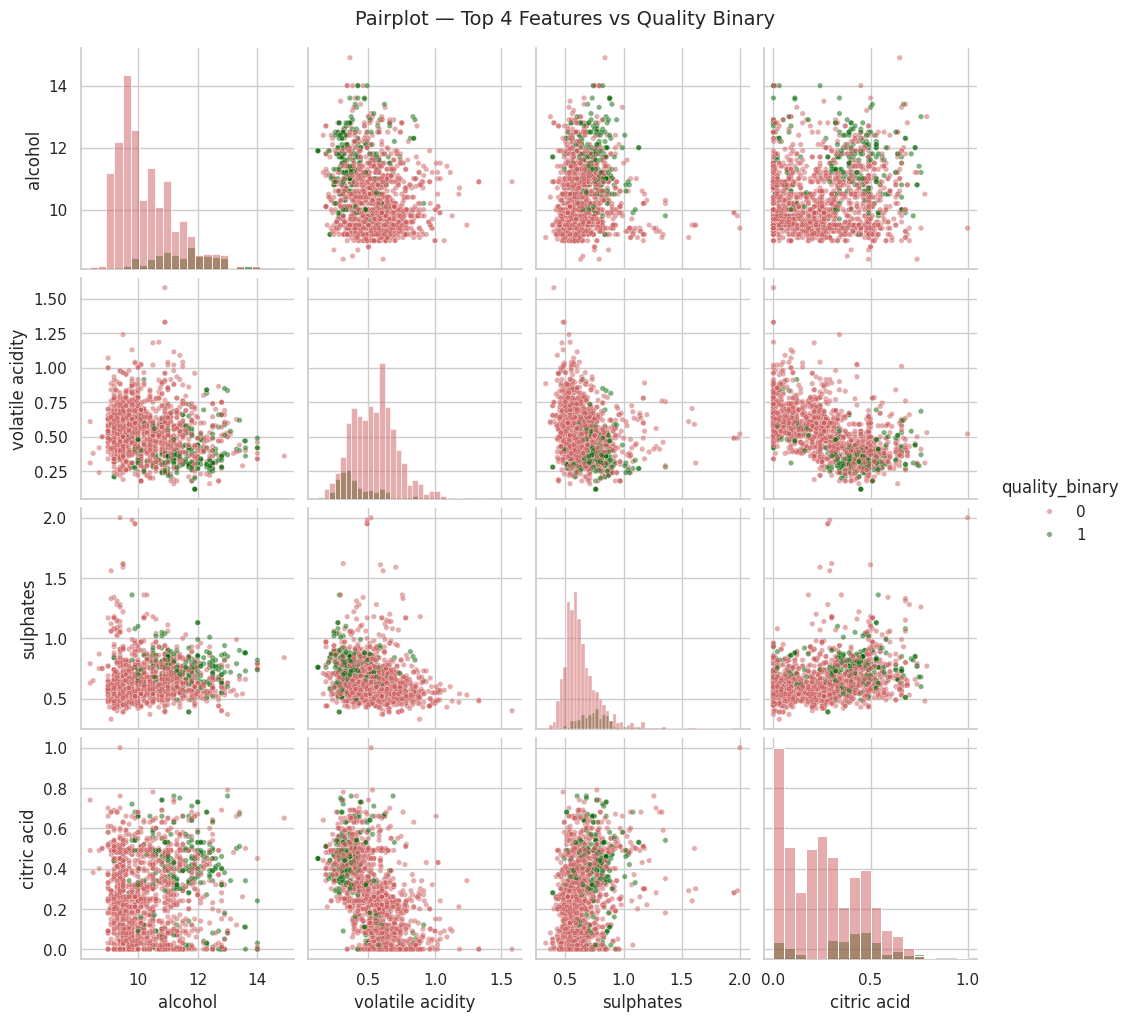

In [18]:
# Seleccionar top 4 features más correlacionadas con quality
top_features = corr_quality.abs().sort_values(ascending=False).head(4).index.tolist()
print(f"Top features: {top_features}")

sns.pairplot(df, vars=top_features, hue='quality_binary',
             palette={0: '#CD5C5C', 1: '#006400'},
             diag_kind='hist', plot_kws={'alpha': 0.5, 's': 15})
plt.suptitle('Pairplot — Top 4 Features vs Quality Binary', y=1.02, fontsize=14)
plt.show()

## 10. Resumen y Conclusiones

In [19]:
print("=" * 60)
print("RESUMEN EDA — RED WINE QUALITY")
print("=" * 60)
print(f"  Muestras:              {len(df)}")
print(f"  Features:              {len(features)}")
print(f"  Valores nulos:         {df.isnull().sum().sum()}")
print(f"  Duplicados:            {df.duplicated().sum()}")
print(f"  Rango quality:         {df['quality'].min()} - {df['quality'].max()}")
print(f"  Balance (good wine):   {df['quality_binary'].mean():.2%}")
print(f"  Feature más correlac.: {corr_quality.abs().idxmax()} ({corr_quality.abs().max():.3f})")
print("=" * 60)
print("\nObservaciones clave:")
print("  • Dataset desbalanceado: ~13-14% de vinos 'buenos' (quality >= 7)")
print("  • Sin valores nulos — dataset limpio")
print("  • Alcohol es la feature más correlacionada con quality")
print("  • Volatile acidity tiene correlación negativa fuerte con quality")
print("  • Outliers significativos en: residual sugar, chlorides, sulphates")
print("  • Distribuciones asimétricas en varias features → considerar transformaciones")

RESUMEN EDA — RED WINE QUALITY
  Muestras:              1599
  Features:              11
  Valores nulos:         0
  Duplicados:            240
  Rango quality:         3 - 8
  Balance (good wine):   13.57%
  Feature más correlac.: alcohol (0.476)

Observaciones clave:
  • Dataset desbalanceado: ~13-14% de vinos 'buenos' (quality >= 7)
  • Sin valores nulos — dataset limpio
  • Alcohol es la feature más correlacionada con quality
  • Volatile acidity tiene correlación negativa fuerte con quality
  • Outliers significativos en: residual sugar, chlorides, sulphates
  • Distribuciones asimétricas en varias features → considerar transformaciones
